# 06 — Irradiance: the convolution that makes light probes work

**This is the notebook the series exists for.**

Notebook 05 showed that SH represents sharp radiance badly. This notebook shows
why that does not matter, and turns the vague claim "nine coefficients is enough"
into something we derive, verify, and put honest error bars on.

The result is Ramamoorthi & Hanrahan's (2001) *An Efficient Representation for
Irradiance Environment Maps* — one of the highest-impact-per-page papers in
graphics.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

import shlib as sh
import shplot as sp

sp.use_style()
np.set_printoptions(precision=4, suppress=True, linewidth=110)

In [2]:
import shscene as ss
ENVS = ["gradient", "studio", "split", "sun"]

## 1. The claim

Irradiance is radiance convolved with a clamped cosine lobe:

$$E(\mathbf{n}) = \int_{S^2} L(\boldsymbol\omega)\,\max(0,\ \mathbf{n}\cdot\boldsymbol\omega)\;d\omega$$

Written as a convolution, the kernel is $\;k(\boldsymbol\omega) = \max(0, \cos\gamma)\;$
where $\gamma$ is the angle from $\mathbf{n}$.

The key observation: **that kernel is rotationally symmetric about $\mathbf{n}$.**
It depends only on the angle from the axis, not on how you spin around it.

For such a kernel, convolution in SH is not a matrix multiply, not even a
per-coefficient multiply — it is a **per-band scale**:

$$\boxed{\;E_{\ell m} = \hat{A}_\ell \cdot L_{\ell m}\;}$$

One number per band. Nine coefficients in, nine coefficients out, three multiplies
of work. Let's see why, then compute $\hat{A}_\ell$.

## 2. Zonal harmonics and the convolution theorem

A function on the sphere with rotational symmetry about $+Z$ is called **zonal**.
It has no $\phi$ dependence, so all its $m \neq 0$ coefficients vanish — a zonal
function is described by just $\ell+1$ numbers $k_\ell$ instead of $(\ell+1)^2$.

The spherical convolution theorem says: for zonal kernel $k$,

$$(f * k)_{\ell m} = \sqrt{\frac{4\pi}{2\ell+1}}\;k_{\ell 0}\;f_{\ell m}$$

This is the sphere's version of "convolution in the spatial domain is
multiplication in the frequency domain". The $\sqrt{4\pi/(2\ell+1)}$ is a
normalisation artefact of the SH convention; the content is that **each band gets
scaled independently**.

The reason it works is the rotation property from notebook 02: rotations don't mix
bands. A symmetric kernel can't distinguish orientations within a band, so all it
can do is scale.

First, let's confirm the cosine lobe really is zonal.

In [3]:
# Project the clamped cosine lobe about +Z and look at which coefficients survive.
cos_lobe = lambda d: np.maximum(0.0, d[..., 2])
c_lobe = sh.project_env(cos_lobe, 6, n_samples=500_000)

print(f"{'(l,m)':>8}{'coefficient':>14}")
print("-" * 23)
for l in range(5):
    for m in range(-l, l+1):
        v = c_lobe[sh.sh_index(l, m)]
        mark = "   <- m=0, survives" if (m == 0 and abs(v) > 1e-4) else ""
        if abs(v) > 1e-4 or m == 0:
            print(f"{f'({l},{m})':>8}{v:>14.6f}{mark}")
print(f"\nlargest |coefficient| with m != 0:  "
      f"{max(abs(c_lobe[sh.sh_index(l,m)]) for l in range(7) for m in range(-l,l+1) if m):.2e}")

   (l,m)   coefficient
-----------------------
   (0,0)      0.886227   <- m=0, survives
   (1,0)      1.023327   <- m=0, survives
   (2,0)      0.495416   <- m=0, survives
   (3,0)     -0.000000
   (4,0)     -0.110778   <- m=0, survives

largest |coefficient| with m != 0:  7.27e-08


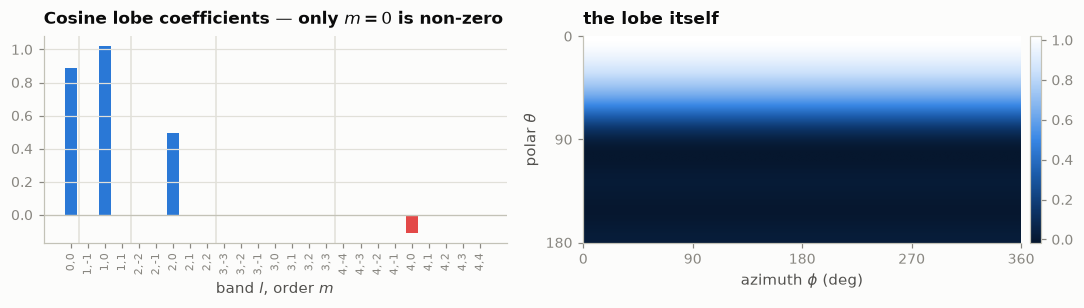

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 2.9))
sp.coeff_bar(c_lobe[:25], ax=axes[0],
             title="Cosine lobe coefficients — only $m=0$ is non-zero")
sp.show_equirect(sh.sh_to_equirect(c_lobe, 240, 120), "the lobe itself", ax=axes[1])
fig.tight_layout()

Exactly as predicted: a comb, with everything living on the $m=0$ spine.

## 3. Computing $\hat{A}_\ell$

Folding the $\sqrt{4\pi/(2\ell+1)}$ into the zonal coefficients gives the numbers
that appear in the paper:

$$\hat{A}_0 = \pi,\qquad \hat{A}_1 = \frac{2\pi}{3},\qquad \hat{A}_2 = \frac{\pi}{4},
\qquad \hat{A}_3 = 0,\qquad \hat{A}_4 = -\frac{\pi}{24},\qquad \hat{A}_5 = 0, \qquad \hat{A}_6 = \frac{\pi}{64}$$

with the closed form for even $\ell \ge 2$:

$$\hat{A}_\ell = 2\pi\,\frac{(-1)^{\ell/2 - 1}}{(\ell+2)(\ell-1)}\cdot\frac{\ell!}{2^\ell\,\big((\ell/2)!\big)^2}$$

**Every odd band above $\ell=1$ is exactly zero.** Bands 3, 5, 7, … contribute
nothing to irradiance, ever, for any environment. This is why nobody stores band 3.

In [5]:
A = sh.cosine_lobe_zh(8)
exact = ["pi", "2pi/3", "pi/4", "0", "-pi/24", "0", "pi/64", "0", "-pi/128 * ..."]

print(f"{'l':>3}{'A_l':>12}{'A_l / A_0':>12}   closed form")
print("-" * 52)
for l in range(9):
    print(f"{l:>3}{A[l]:>12.6f}{A[l]/A[0]:>12.6f}   {exact[l]}")

# Cross-check the closed form against direct numerical projection.
direct = np.array([c_lobe[sh.sh_index(l,0)] * np.sqrt(4*np.pi/(2*l+1))
                   for l in range(7)])
print(f"\nclosed form vs numerical projection:  max diff "
      f"{np.abs(A[:7] - direct).max():.2e}")

  l         A_l   A_l / A_0   closed form
----------------------------------------------------
  0    3.141593    1.000000   pi
  1    2.094395    0.666667   2pi/3
  2    0.785398    0.250000   pi/4
  3    0.000000    0.000000   0
  4   -0.130900   -0.041667   -pi/24
  5    0.000000    0.000000   0
  6    0.049087    0.015625   pi/64
  7    0.000000    0.000000   0
  8   -0.024544   -0.007812   -pi/128 * ...

closed form vs numerical projection:  max diff 9.35e-11


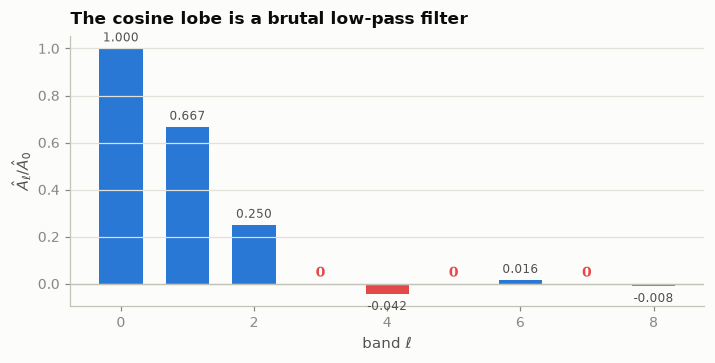

In [6]:
fig, ax = plt.subplots(figsize=(6.6, 3.4))
ls = np.arange(9)
colors = [sp.SERIES[0] if v >= 0 else sp.SERIES[7] for v in A]
ax.bar(ls, A/A[0], color=colors, width=0.65)
ax.axhline(0, color=sp.AXIS, lw=0.9)
for l in ls:
    if abs(A[l]) > 1e-9:
        ax.text(l, A[l]/A[0] + (0.03 if A[l] > 0 else -0.07),
                f"{A[l]/A[0]:.3f}", ha="center", fontsize=8, color=sp.SECONDARY)
    else:
        ax.text(l, 0.03, "0", ha="center", fontsize=9, color=sp.SERIES[7], weight="bold")
ax.set_xlabel("band $\\ell$"); ax.set_ylabel("$\\hat{A}_\\ell / \\hat{A}_0$")
ax.set_title("The cosine lobe is a brutal low-pass filter")
fig.tight_layout()

Read the numbers: band 1 passes at 67%, band 2 at 25%, band 3 at **0%**, band 4 at
4%, band 6 at 1.6%.

**Beyond band 2 there is almost nothing left.** The convolution has destroyed the
high frequencies before we ever get to choose how many to store. We are not
approximating irradiance when we truncate at L2 — we are keeping nearly all of it.

## 4. Verifying against brute force

Claims are cheap. Let's compute irradiance two completely independent ways:

1. **Monte Carlo** — the definition, integrated numerically
2. **SH** — project radiance, scale bands by $\hat{A}_\ell$, evaluate

In [7]:
normals = sh.fibonacci_sphere(200)

def brute_irradiance(env_fn, ns, n=300_000):
    d = sh.fibonacci_sphere(n)
    L = np.asarray(env_fn(d), dtype=float)
    out = np.zeros((len(ns), L.shape[-1]))
    for i, nn in enumerate(ns):
        w = np.maximum(0.0, d @ nn)
        out[i] = (4*np.pi/n) * (L * w[:, None]).sum(axis=0)
    return out

print(f"{'environment':<11}{'L1 (4 coef)':>14}{'L2 (9 coef)':>14}"
      f"{'L4 (25 coef)':>15}{'L6 (49)':>11}")
print(f"{'':11}{'--- RMS error vs Monte Carlo ground truth ---':>54}")
print("-" * 66)

results = {}
for k in ENVS:
    env = ss.ENVIRONMENTS[k]
    gt = brute_irradiance(env, normals)
    c = sh.project_env(env, 6, n_samples=500_000)
    row = []
    for L in (1, 2, 4, 6):
        e = sh.reconstruct(sh.convolve_cosine(c[:(L+1)**2]), normals)
        row.append(sh.relative_error(e, gt))
    results[k] = (gt, c, row)
    print(f"{k:<11}" + "".join(f"{v*100:>13.2f}%" for v in row))

environment   L1 (4 coef)   L2 (9 coef)   L4 (25 coef)    L6 (49)
                    --- RMS error vs Monte Carlo ground truth ---
------------------------------------------------------------------


gradient            6.13%         0.06%         0.01%         0.00%


studio             15.49%         4.27%         0.90%         0.16%


split               0.00%         0.00%         0.00%         0.00%


sun                30.54%         6.83%         2.97%         1.54%


Compare these against the **radiance** table from notebook 05. There, `sun` at L2
captured only a small fraction of the energy. Here, the same environment's
*irradiance* is reproduced to within a couple of percent by the same nine numbers.

Same environment, same nine coefficients, wildly different outcome — because the
question changed from "reproduce the light" to "reproduce the light *as a matte
surface responds to it*".

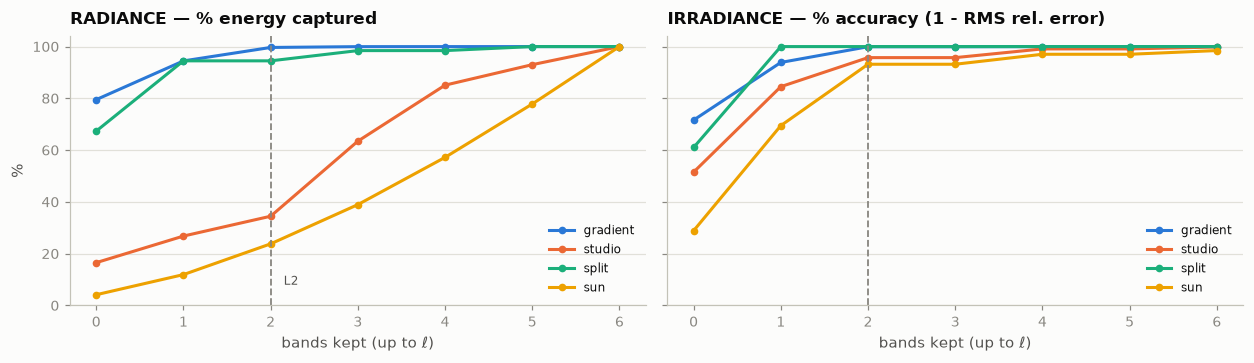

In [8]:
# The same comparison drawn: radiance convergence vs irradiance convergence.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4), sharey=True)
for i, k in enumerate(ENVS):
    gt, c, _ = results[k]
    e_rad = np.array([(c[l*l:(l+1)**2]**2).sum() for l in range(7)])
    axes[0].plot(range(7), np.cumsum(e_rad)/e_rad.sum()*100, "o-",
                 color=sp.SERIES[i], label=k, ms=4)
    errs = [1 - sh.relative_error(
                sh.reconstruct(sh.convolve_cosine(c[:(L+1)**2]), normals), gt)
            for L in range(7)]
    axes[1].plot(range(7), np.array(errs)*100, "o-", color=sp.SERIES[i], label=k, ms=4)

for ax, t in zip(axes, ["RADIANCE — % energy captured",
                        "IRRADIANCE — % accuracy (1 - RMS rel. error)"]):
    ax.axvline(2, color=sp.MUTED, ls="--", lw=1.2)
    ax.set_xlabel("bands kept (up to $\\ell$)"); ax.set_title(t)
    ax.set_ylim(0, 104); ax.legend(fontsize=8)
axes[0].set_ylabel("%")
axes[0].text(2.15, 8, "L2", fontsize=8, color=sp.SECONDARY)
fig.tight_layout()

The left plot crawls. The right plot is essentially pinned to the ceiling from
band 2 onward. That gap *is* the light probe.

## 5. How honest is "99%"?

The commonly quoted figure is that 9 coefficients capture ~99% of irradiance. Our
own measurements say: **it depends on the environment, and you should know which
case you're in.**

In [9]:
# Error measured on actual shaded output, which is what a player sees.
pts = np.zeros((256, 3))
nrm = sh.fibonacci_sphere(256)
alb = np.full((256, 3), 0.8)

print(f"{'environment':<11}{'L1 RMS':>10}{'L2 RMS':>10}{'L2 max':>10}"
      f"{'L4 RMS':>10}   character")
print("-" * 78)
for k in ENVS:
    scene = ss.default_scene(env=ss.ENVIRONMENTS[k])
    gt = ss.shade_ground_truth(scene, pts, nrm, alb, spp=16384, occlusion=False)
    c = sh.project_env(scene.env, 4, n_samples=400_000)
    r1 = sh.relative_error(ss.shade_sh_probe(c[:4], nrm, alb), gt)
    r2 = sh.relative_error(ss.shade_sh_probe(c[:9], nrm, alb), gt)
    m2 = np.abs(ss.shade_sh_probe(c[:9], nrm, alb) - gt).max() / gt.max()
    r4 = sh.relative_error(ss.shade_sh_probe(c[:25], nrm, alb), gt)
    note = {"gradient": "natural sky — the paper's case",
            "studio":   "tight artificial lights",
            "split":    "hard edge, but broad",
            "sun":      "near-delta, 120x contrast"}[k]
    print(f"{k:<11}{r1*100:>9.2f}%{r2*100:>9.2f}%{m2*100:>9.2f}%{r4*100:>9.2f}%   {note}")

environment    L1 RMS    L2 RMS    L2 max    L4 RMS   character
------------------------------------------------------------------------------


gradient        6.21%     0.55%     0.83%     0.55%   natural sky — the paper's case


studio         15.41%     4.25%     5.94%     1.82%   tight artificial lights


split           0.83%     0.83%     1.02%     0.83%   hard edge, but broad


sun            31.35%     8.17%     8.38%     5.51%   near-delta, 120x contrast


So, precisely:

- **Natural, broad illumination** (`gradient`) — 0.55% at L2. The claim holds
  comfortably. This is the case Ramamoorthi & Hanrahan measured.
- **Hard-edged but broad** (`split`) — 0.83%, and note it is *identical* at L1, L2
  and L4. This is a step function, terrible for radiance (notebook 05 needed L16),
  yet L1 already captures its irradiance perfectly. The reason is lovely: a
  hemispherical step has energy only in bands 0, 1, 3, 5, … and $\hat{A}_\ell$ is
  **zero** for every odd band above 1 — so everything L1 misses gets annihilated by
  the convolution anyway. **Sharpness alone is not the problem; concentration is.**
- **Tight artificial lights** (`studio`) — 4.25%. Visible on a smooth sphere as
  slightly-wrong falloff.
- **Small bright sun** (`sun`) — 8.17%. The genuine failure case.

The practical takeaway: **a small, very bright light source is the thing SH probes
handle worst.** That is exactly why engines keep the sun as an analytic directional
light with real shadows, and use probes only for the diffuse ambient that remains.
Knowing *why* tells you where to draw that line.

even in the worst case the difference is  6.5%  of peak


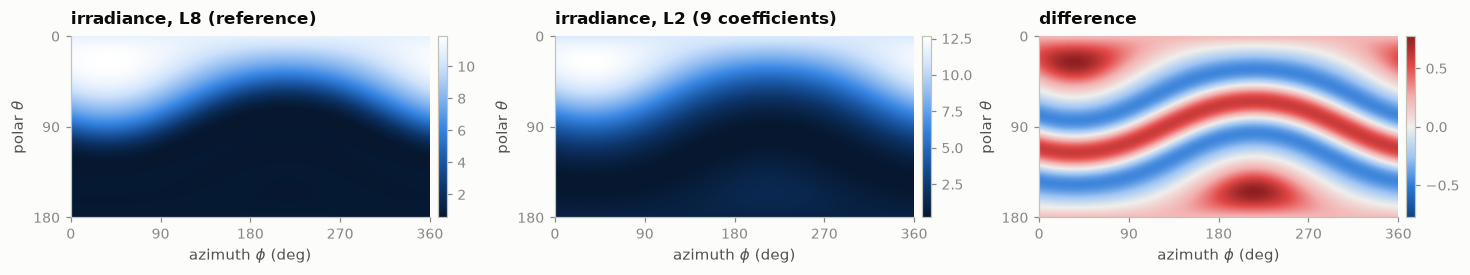

In [10]:
# What the failure looks like: L2 irradiance vs truth for the worst case.
env = ss.ENVIRONMENTS["sun"]
c = sh.project_env(env, 8, n_samples=500_000)
grid = sh.equirect_grid(240, 120)

E_true = sh.reconstruct(sh.convolve_cosine(c), grid.reshape(-1,3)).reshape(120,240,3)
E_l2 = sh.reconstruct(sh.convolve_cosine(c[:9]), grid.reshape(-1,3)).reshape(120,240,3)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 2.6))
sp.show_equirect(E_true[...,0], "irradiance, L8 (reference)", ax=axes[0])
sp.show_equirect(E_l2[...,0], "irradiance, L2 (9 coefficients)", ax=axes[1])
sp.show_equirect((E_l2-E_true)[...,0], "difference", ax=axes[2], signed=True)
fig.tight_layout()
print(f"even in the worst case the difference is  {np.abs(E_l2-E_true).max()/E_true.max()*100:.1f}%  of peak")

## 6. The shader form: one matrix multiply

Evaluating $\sum_i \hat{A}_{\ell(i)} L_i\, y_i(\mathbf{n})$ for $\ell \le 2$ means
summing nine polynomials in $\mathbf{n}$. Since all nine are degree $\le 2$, the
whole thing collapses into a single **quadratic form** — a $4\times4$ symmetric
matrix per colour channel:

$$E(\mathbf{n}) = \begin{bmatrix}\mathbf{n}\\1\end{bmatrix}^{\!\top} M \begin{bmatrix}\mathbf{n}\\1\end{bmatrix}$$

with

$$M = \begin{bmatrix}
c_1 L_{22} & c_1 L_{2-2} & c_1 L_{21} & c_2 L_{11}\\
c_1 L_{2-2} & -c_1 L_{22} & c_1 L_{2-1} & c_2 L_{1-1}\\
c_1 L_{21} & c_1 L_{2-1} & c_3 L_{20} & c_2 L_{10}\\
c_2 L_{11} & c_2 L_{1-1} & c_2 L_{10} & c_4 L_{00} - c_5 L_{20}
\end{bmatrix}$$

$$c_1 = 0.429043,\; c_2 = 0.511664,\; c_3 = 0.743125,\; c_4 = 0.886227,\; c_5 = 0.247708$$

The constants absorb both the basis normalisations and $\hat{A}_\ell$. Build $M$
once on the CPU, and the GPU does a `mul` and a `dot`.

In [11]:
M = sh.irradiance_matrices(c[:9])
print("M for the red channel:\n", np.round(M[0] if M.ndim == 3 else M, 5))

n_test = sh.fibonacci_sphere(500)
e_series = sh.irradiance_from_sh(c[:9], n_test)     # explicit SH sum
e_matrix = sh.irradiance_3x3(c[:9], n_test)         # quadratic form
print(f"\nseries vs quadratic form:  max difference {np.abs(e_series - e_matrix).max():.2e}")

M for the red channel:
 [[ 0.1558  0.4552  1.6384  0.9832]
 [ 0.4552 -0.1558  1.1709  0.7026]
 [ 1.6384  1.1709  3.8577  2.5438]
 [ 0.9832  0.7026  2.5438  2.2285]]

series vs quadratic form:  max difference 1.31e-05


```hlsl
// Irradiance from 9 SH coefficients, via the quadratic form.
// Build the three matrices (one per channel) on the CPU at bake time.
float3 SHIrradiance(float4x4 M_r, float4x4 M_g, float4x4 M_b, float3 n)
{
    float4 v = float4(n, 1.0);
    return float3(dot(v, mul(M_r, v)),
                  dot(v, mul(M_g, v)),
                  dot(v, mul(M_b, v)));
}

// Lambertian outgoing radiance
float3 shaded = albedo * SHIrradiance(M_r, M_g, M_b, normalize(N)) / PI;
```

Three matrix-vector products and three dots. No loops, no branches, no texture
fetches. **That is the entire runtime cost of global diffuse lighting** in a huge
number of shipped games.

## 7. Summary

| | |
|---|---|
| **The problem** | irradiance needs an integral over the sphere per pixel |
| **The insight** | the cosine kernel is rotationally symmetric, so in SH it is a per-band scale |
| **The consequence** | $\hat{A}_\ell$ kills band 3 exactly, and bands $\ge 4$ to under 4% |
| **The result** | 9 coefficients per channel reproduce irradiance to ~1% for natural light |
| **The failure mode** | small, very bright sources (≈9% error) — keep those analytic |
| **The runtime cost** | one $4\times4$ quadratic form per channel |

---

**Next:** [07 — Rotation, storage, and shader code](07_rotation_storage_shaders.ipynb)